### 1 Setup

#### Import Libraries

In [1]:
# Data manipulation libraries.
import numpy as np
import pandas as pd

# Data visualization libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Data modeling libraries.
from sklearn.tree import DecisionTreeClassifier, plot_tree

#### Configure Libraries

In [2]:
# Configure NumPy.
rng = np.random.default_rng(seed=42)
np.set_printoptions(linewidth=100)

# Configure Pandas.
pd.options.display.width = 100
pd.options.display.max_columns = None

# Configure Seaborn.
# sns.set_style("whitegrid")
sns.set_palette("deep")

#### Import Dataset

In [3]:
emp_df = pd.read_csv("data/employee_attrition.csv")

display(emp_df.sample(3, random_state=rng))

row_count, col_count = emp_df.shape
print(f"Dataset contains {row_count} rows and {col_count} columns.")

,age,ot_hrs,attrition
45,22.4,1.1,0
6,46.1,1.5,0
53,35.9,3.4,0


Dataset contains 70 rows and 3 columns.


In [4]:
emp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        70 non-null     float64
 1   ot_hrs     70 non-null     float64
 2   attrition  70 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 1.8 KB


### 2 EDA

#### Target Variable

In [5]:
emp_df["attrition"].value_counts()

attrition
0    42
1    28
Name: count, dtype: int64

#### Features

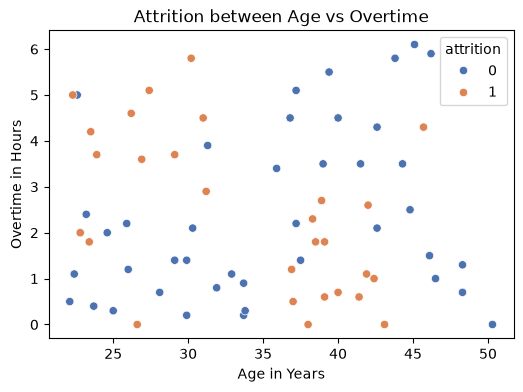

In [6]:
plt.figure(figsize=(6, 4))

sns.scatterplot(data=emp_df, x="age", y="ot_hrs", hue="attrition")
plt.title("Attrition between Age vs Overtime")
plt.xlabel("Age in Years")
plt.ylabel("Overtime in Hours")

plt.show()

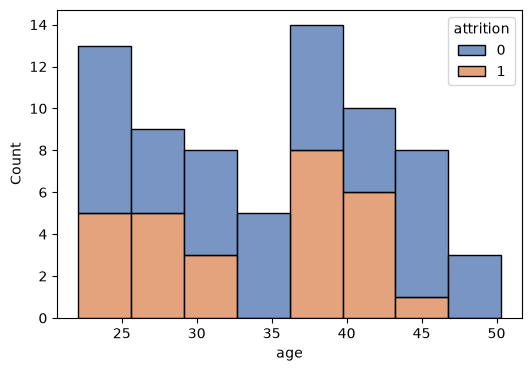

In [7]:
plt.figure(figsize=(6, 4))
sns.histplot(data=emp_df, x="age", hue="attrition", multiple="stack")
plt.show()

In [8]:
def value_count(x):
    """
    Function to return most common class label in
    the input array `x` based on its value count.
    """
    return np.bincount(x).argmax().item()

In [9]:
emp_df2 = emp_df.copy()

oth_bins = [0, 1, 2, 3, 4, 5, 6]
oth_lbls = ["0-1", "1-2", "2-3", "3-4", "4-5", "5-6"]
age_bins = [20, 25, 30, 35, 40, 45, 50]
age_lbls = ["20-25", "25-30", "30-35", "35-40", "40-45", "45-50"]

emp_df2["oth_bins"] = pd.cut(emp_df2["ot_hrs"], bins=oth_bins, labels=oth_lbls)
emp_df2["age_bins"] = pd.cut(emp_df2["age"], bins=age_bins, labels=age_lbls)

camt = emp_df2.pivot_table(
    index="oth_bins",
    columns="age_bins",
    values="attrition",
    aggfunc=lambda x: np.bincount(x).argmax().item(),
)

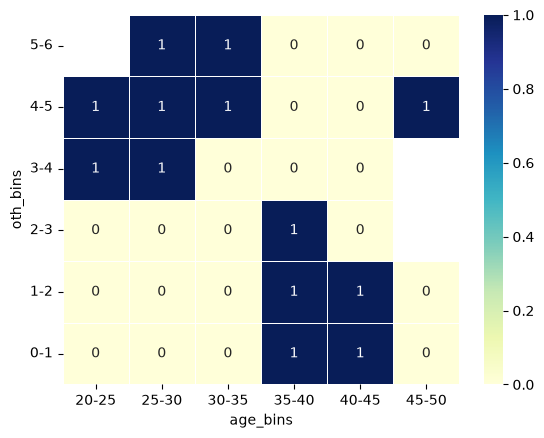

In [10]:
ax = sns.heatmap(camt, cmap="YlGnBu", linecolor="white", linewidth=0.5, annot=True)
ax.invert_yaxis()
plt.yticks(rotation=0)
plt.show()

### 3 Decision Tree

#### Training Setup

In [11]:
X_train = emp_df[emp_df.columns.difference(["attrition"])]
y_train = emp_df["attrition"]

#### Training Decision Tree Classifier

In [12]:
clf = DecisionTreeClassifier(criterion="gini", max_leaf_nodes=5, random_state=42)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

#### Plot Decision Tree

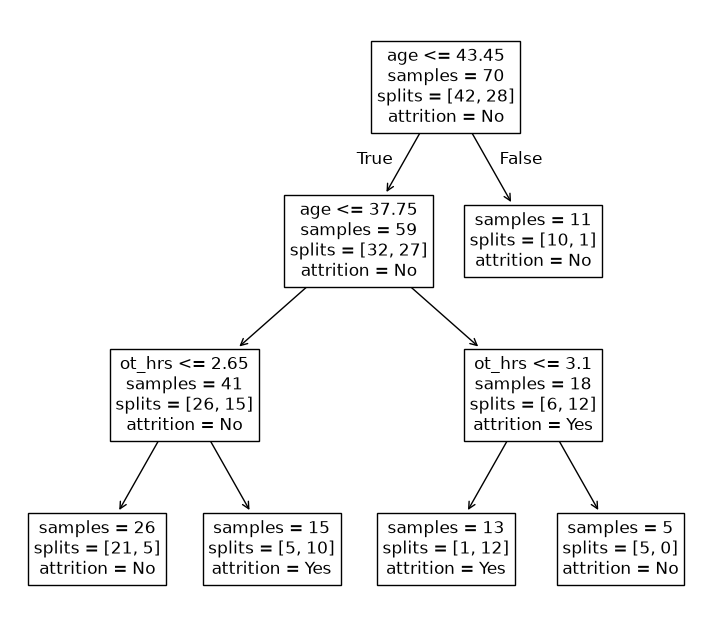

In [13]:
plt.figure(figsize=(9, 8))

plot_tree(clf, feature_names=X_train.columns, class_names=["No", "Yes"], fontsize=12, impurity=False)

for annot in plt.gca().texts:
    text = annot.get_text()
    text = text.replace("value =", "splits =")
    text = text.replace("class =", "attrition =")
    annot.set_text(text)

# plt.savefig("images/2_emp_att_dt.png", bbox_inches="tight")
plt.show()